Raz Leisbon & Demain Stoianov

# Starter notebook – Unsupervised learning (rat electrophysiology)

This notebook **loads the data and shows what it looks like**. It does not solve any of the tasks.
Use it as the starting point of your own notebook: keep what is useful, delete the rest.

The full task description is in [`README.md`](README.md) in this folder.

**Contents**
1. Load the data
2. A first look at the features
3. Checking your output file (Task 2)

## 0. Setup

In [1]:
# Setup: works both on your own computer and in Google Colab.
# In Colab, this cell downloads the course repository (with the data) and moves into it.
import os, sys

REPO_URL = "https://github.com/deutschlab/computational-ethology-final-project.git"   # course repository
PART = "unsupervised"

if "google.colab" in sys.modules and not os.path.exists("data"):
    !git clone --depth 1 {REPO_URL} course_repo
    %cd course_repo/{PART}

print("Data files:", sorted(os.listdir("data")))

Cloning into 'course_repo'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 25 (delta 1), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 133.20 MiB | 27.44 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/course_repo/unsupervised
Data files: ['electrophysiology_data.csv']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the data

The first column of the file only holds the row number. It is not a feature, so we drop it.

In [ ]:
raw = pd.read_csv("data/electrophysiology_data.csv")
print("Columns in the file:", list(raw.columns))

data = raw.drop(columns=raw.columns[0])     # drop the unnamed row-number column
print("Shape after dropping it:", data.shape)
data.head()

Columns in the file: ['Unnamed: 0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8']
Shape after dropping it: (62, 8)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8
0,7.766982,0.242468,2.451400,1.736200,-0.089253,-0.017794,-0.036484,0.312714
1,17.940081,0.261169,0.729700,2.098900,-0.189602,-0.020596,-0.054364,0.381867
2,3.595100,0.174408,0.900318,-0.089208,-0.036845,-0.002994,0.001233,0.105970
3,1.673900,0.162970,0.914393,-0.365906,-0.025686,-0.000676,0.008585,0.069576
4,8.588500,0.204138,0.863736,0.629957,-0.065850,-0.009018,-0.017877,0.200561


## 2. A first look at the features

The table shows the mean, standard deviation and range of each feature.
Look at the scales: are the features measured in comparable units?

In [ ]:
data.describe().round(3)

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8
count,62.000,62.000,62.000,62.000,62.000,62.000,62.000,62.000
mean,8.514,0.204,0.864,0.619,-0.065,-0.009,-0.018,0.199
std,3.075,0.113,0.536,0.639,0.035,0.022,0.046,0.149
min,1.674,0.004,-0.500,-0.774,-0.190,-0.121,-0.211,-0.004
25%,6.765,0.167,0.631,0.160,-0.087,-0.014,-0.032,0.104
50%,8.297,0.204,0.855,0.619,-0.066,-0.009,-0.018,0.199
75%,10.767,0.226,0.949,1.088,-0.047,-0.003,-0.003,0.272
max,17.940,0.694,3.210,2.527,0.008,0.059,0.152,0.781


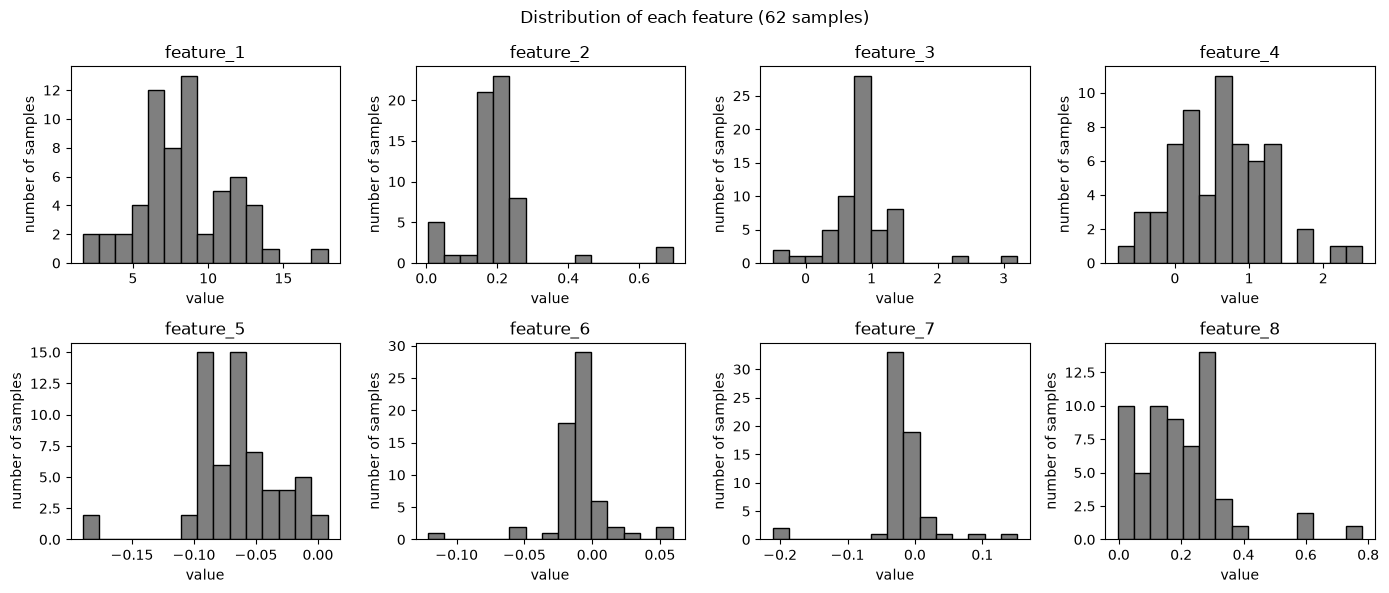

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), data.columns):
    ax.hist(data[col], bins=15, color="tab:gray", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("number of samples")
fig.suptitle("Distribution of each feature (62 samples)")
plt.tight_layout()
plt.show()

Note the different x-axis ranges of the panels, and any samples that sit far from the rest.
Both matter for the dimensionality reduction and clustering tasks.

> **UMAP** is not installed in Colab by default. Run `!pip install umap-learn` once, then `import umap`.

## 3. Checking your output file (Task 2)

**What the file should look like, in words:** the original data table, with **one extra last column `kmeans_labels`** holding the cluster number of each sample. So: 62 rows, the 8 feature columns with their original names and their **original, unscaled values** in the **original row order**, then `kmeans_labels`. No row-number column. The first lines look like this (your cluster numbers will differ):

```
feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,kmeans_labels
7.766982073,0.242468358,2.4514,1.7362,-0.089252858,-0.017793895,-0.036483548,0.312714272,1
17.94008088,0.261168681,0.7297,2.0989,-0.189602497,-0.020596076,-0.0543638,0.381866697,0
```

Example of saving it, where `kmeans` is your fitted KMeans model (fitted on the scaled data is fine; the file still gets the original values):

```python
data_with_labels = data.copy()                       # `data` = the original, unscaled features
data_with_labels["kmeans_labels"] = kmeans.labels_
data_with_labels.to_csv("electrophysiology_data_kmeans.csv", index=False)
```

Before you submit, run the function below on the file. It reports **problems** (fix these before you submit; each message says how) and **warnings** (usually fine, but have a look). It cannot check whether your clusters are "right": there is no single right answer.
If it reports a problem that you cannot fix, submit anyway and write a sentence about it in your notebook or in an email to us.


In [ ]:
def check_kmeans_file(path, original_path="data/electrophysiology_data.csv"):
    """Check the format of electrophysiology_data_kmeans.csv against the original data file.

    Prints PROBLEMS (fix these before you submit) and WARNINGS (usually fine, but look).
    It cannot check whether your clusters are "right": there is no single right answer.
    """
    raw = pd.read_csv(original_path)
    original = raw.drop(columns=raw.columns[0])
    features = list(original.columns)
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"{path}: file not found. Did you save it, and in the current folder?")
        return
    problems, warnings = [], []
    cols = list(df.columns)

    index_cols = [c for c in cols if str(c).startswith("Unnamed")]
    if index_cols:
        problems.append("the file has a row-number column (you saved the index). "
                        "Save it with to_csv(..., index=False).")
    missing = [c for c in features if c not in cols]
    if missing:
        problems.append(f"feature columns missing: {missing}. The file must contain the 8 original "
                        "feature columns with their original names.")
    label_col = "kmeans_labels"
    if label_col not in cols:
        similar = [c for c in cols if c not in features + index_cols]
        hint = f" (did you mean {similar}? rename it)" if similar else ""
        problems.append(f"no column named 'kmeans_labels'{hint}.")
    extra = [c for c in cols if c not in features + [label_col] + index_cols]
    if extra and label_col in cols:
        warnings.append(f"extra columns {extra} will be ignored; the file only needs the 8 features and 'kmeans_labels'.")
    if not missing and label_col in cols and cols != features + [label_col] and not index_cols and not extra:
        warnings.append("the columns are not in the original order (8 features, then 'kmeans_labels').")

    if len(df) != len(original):
        msg = f"{len(df)} rows, expected {len(original)}."
        if len(df) < len(original):
            msg += " Did you drop rows (for example outliers)? Every one of the 62 samples needs a label."
        problems.append(msg)

    if not missing and len(df) == len(original):
        a = df[features].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
        b = original.to_numpy(dtype=float)
        if np.isnan(a).any():
            problems.append("some feature values are missing or are not numbers.")
        elif np.allclose(a, b, rtol=1e-6, atol=1e-6):
            pass
        elif np.allclose(a, b, rtol=1e-2, atol=1e-2):
            warnings.append("the feature values are rounded; better save them exactly as in the original file.")
        elif abs(a.mean()) < 0.1 and abs(a.std() - 1) < 0.2:
            problems.append("the feature values look standardized (mean 0, std 1). "
                            "Save the ORIGINAL, unscaled features (add the labels to the original data frame).")
        elif np.allclose(np.sort(a, axis=0), np.sort(b, axis=0), rtol=1e-6, atol=1e-6):
            problems.append("the rows are in a different order than in the original file (did you sort or shuffle?). "
                            "Keep the original row order.")
        else:
            problems.append("the feature values differ from the original data. "
                            "Save the original, unscaled features, in the original row order.")

    labels = None
    if label_col in cols:
        labels = pd.to_numeric(df[label_col], errors="coerce")
        if labels.isna().any():
            problems.append("'kmeans_labels' has missing values or values that are not numbers.")
        elif not np.all(np.mod(labels, 1) == 0):
            problems.append("'kmeans_labels' must be whole numbers (cluster numbers such as 0, 1, 2).")
        elif labels.nunique() == 1:
            warnings.append("all samples have the same cluster label.")

    ok_text = None
    if labels is not None and not problems:
        sizes = labels.astype(int).value_counts().sort_index().to_dict()
        ok_text = f"{labels.nunique()} clusters, sizes {sizes}"
    _report(path, problems, warnings, ok_text)


def _report(path, problems, warnings, ok_text):
    if problems:
        print(f"{path}: PROBLEMS FOUND - please fix before you submit")
        for p in problems:
            print("  - PROBLEM:", p)
    else:
        print(f"{path}: OK ({ok_text})")
    for w in warnings:
        print("  - warning:", w)


# Uncomment when your file exists:
# check_kmeans_file("electrophysiology_data_kmeans.csv")
